In [1]:
import matplotlib.pyplot as plt
import numpy as np
import json
import os
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [2]:
# OUTPUT_PATH = '/home/oluwatobi-alao/workspace/research/hiring-dss-research/data/simulation/output/final/workflow'
OUTPUT_PATH = '/Users/tobialao/workspace/research/hiring-dss-research/data/simulation/output/final/workflow'
EVAL_PATH = '/Users/tobialao/workspace/research/hiring-dss-research/data/simulation/output/evaluation'


In [3]:
test_cases = []

model_map = {
    '8b_Q4': 'workflow_8b_Q4',
    '8b_Q8': 'workflow_8b_Q8',
    '8b_QF16': 'workflow_8b',
    'openai': 'workflow_openai',
}


def extract_inference_time(data):
    result = {}
    for key in data:
        result[key] = [obj['processing_time'] for obj in data[key]]
    return result


def load_data(path: str):
    result = {}
    files = os.listdir(path)
    for file in files:
        if file.endswith('.json'):
            code = file.split('.')[0].split('_')[-1]
            with open(os.path.join(path, file), 'r') as f:
                result[code] = json.load(f)
    return result


def merge_objects(primary_list, secondary_list):
    """
    Merges two lists of dictionaries based on matching 'question_id' (from primary) and 'id' (from secondary).
    Returns a merged list of dictionaries.
    """
    # Build a mapping from id to secondary object
    secondary_map = {item.get('id'): item for item in secondary_list}

    merged = []

    for obj in primary_list:
        question_id = obj.get("question_id")

        # Try to find a matching secondary object
        secondary_obj = secondary_map.get(question_id)

        # If found, merge the dictionaries
        if secondary_obj:
            merged_obj = {
                **obj,  # Start with all fields from the primary object
                "context": obj.get("context")[0],
                "correct": secondary_obj.get("correct"),
                "answer_relevant": secondary_obj.get("answer_relevant"),
                "context_relevant": secondary_obj.get("context_relevant"),
                "relevancy_score": secondary_obj.get("relevancy_score"),
                "context_relevancy_score": secondary_obj.get("context_relevancy_score"),
                "relevancy_reason": secondary_obj.get("relevancy_reason"),
                "context_relevancy_reason": secondary_obj.get("context_relevancy_reason"),
                "path": secondary_obj.get("path"),
                "path_len": secondary_obj.get("path_len"),
            }
            del merged_obj["processing_path"]
            del merged_obj["power_consumption"]
            del merged_obj["error"]
            merged.append(merged_obj)
        else:
            # If no match, you may choose to keep the original object or skip
            merged.append(obj)

    return merged


In [4]:
model_inference_data = {}
model_full_data = {}
for key in model_map:
    simulation_data = load_data(os.path.join(OUTPUT_PATH, model_map[key]))
    evaluation_data = load_data(os.path.join(EVAL_PATH, key))
    tc_merged = {}
    for tc in simulation_data:
        tc_merged[tc] = merge_objects(simulation_data[tc], evaluation_data[tc])
    model_full_data[key] = tc_merged
    model_inference_data[key] = extract_inference_time(simulation_data)


In [5]:
full_evaluation_data = model_full_data.copy()

In [6]:
for key in model_full_data:
    for tc in model_full_data[key]:
        for item in model_full_data[key][tc]:
            del item["expected_output"]
            del item["prompt"]
            del item["model_response"]
            del item["context"]
            del item["relevancy_reason"]
            del item["context_relevancy_reason"]

In [7]:
# with open('eval_output_combined.json', 'w') as f:
#     json.dump(model_full_data, f, indent=2)

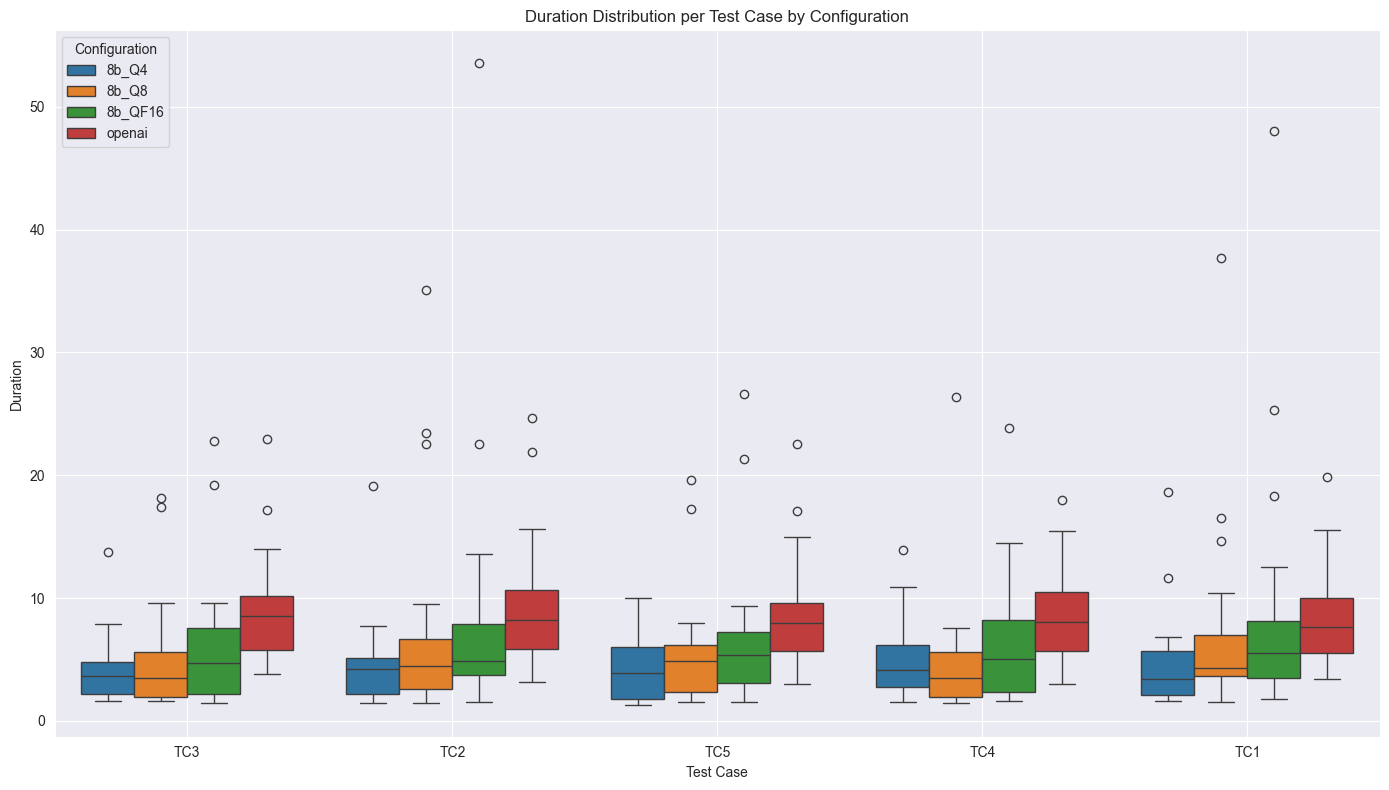

In [8]:
# Flatten data into a DataFrame suitable for box plots
rows = []
for config, tests in model_inference_data.items():
    for tc_name, values in tests.items():
        for value in values:
            rows.append({
                'Configuration': config,
                'Test Case': tc_name,
                'Duration': value
            })

df = pd.DataFrame(rows)

# Set up the plot
plt.figure(figsize=(14, 8))
sns.boxplot(x='Test Case', y='Duration', hue='Configuration', data=df)
plt.title('Duration Distribution per Test Case by Configuration')
plt.ylabel('Duration')
plt.grid(True)
plt.legend(title='Configuration')
plt.tight_layout()
plt.show()

In [9]:
df.tail()

,Configuration,Test Case,Duration
595,openai,TC1,5.527511
596,openai,TC1,10.883523
597,openai,TC1,6.742881
598,openai,TC1,4.898973
599,openai,TC1,9.624484


In [10]:
# Calculate mean duration per Test Case per Configuration
mean_df = df.groupby(['Configuration', 'Test Case'])['Duration'].mean().reset_index()

# Pivot for plotting
pivot_df = mean_df.pivot(index='Test Case', columns='Configuration', values='Duration')


In [11]:
mean_df.head(20)

,Configuration,Test Case,Duration
0,8b_Q4,TC1,4.468459
1,8b_Q4,TC2,4.395898
2,8b_Q4,TC3,4.033041
3,8b_Q4,TC4,4.975355
4,8b_Q4,TC5,4.138623
5,8b_Q8,TC1,6.500612
6,8b_Q8,TC2,6.717659
7,8b_Q8,TC3,4.751742
8,8b_Q8,TC4,4.633774
9,8b_Q8,TC5,5.291400


In [12]:
pivot_df.head(20)

Configuration,8b_Q4,8b_Q8,8b_QF16,openai
Test Case,,,,
TC1,4.468459,6.500612,7.843654,8.229149
TC2,4.395898,6.717659,7.618480,9.228170
TC3,4.033041,4.751742,5.849368,8.875047
TC4,4.975355,4.633774,6.154263,8.763424
TC5,4.138623,5.291400,6.266748,8.649088


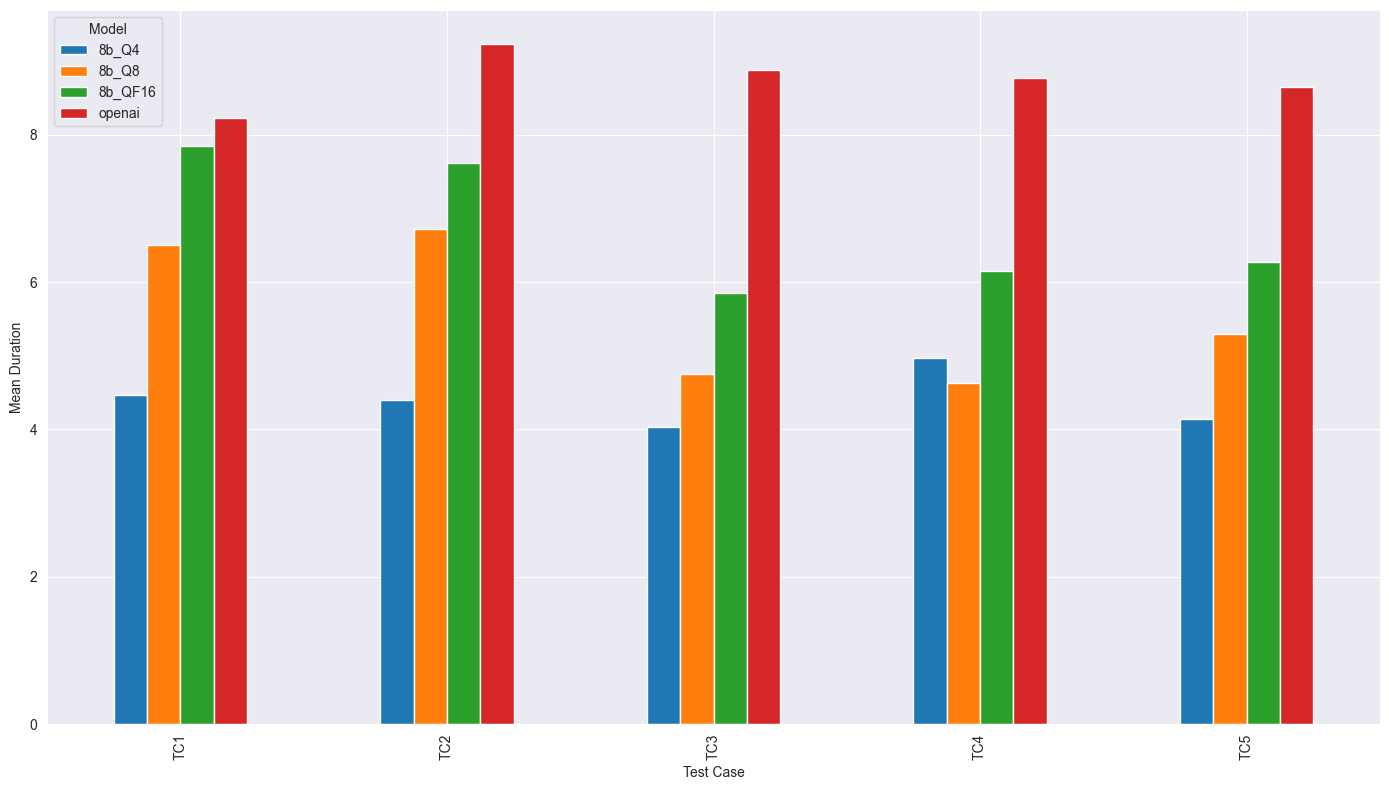

In [13]:
# Plotting bar chart
pivot_df.plot(kind='bar', figsize=(14, 8))
plt.title('')
plt.ylabel('Mean Duration')
plt.xlabel('Test Case')
plt.grid(True, axis='y')
plt.legend(title='Model')
plt.tight_layout()
plt.show()


In [14]:
# Flatten the nested JSON structure
records = []
for model_id, batches in model_full_data.items():
    for batch_id, evaluations in batches.items():
        for record in evaluations:
            record_flat = record.copy()
            record_flat["model_id"] = model_id
            records.append(record_flat)

# Convert to DataFrame
df = pd.DataFrame(records)
df["throughput"] = (df["response_token_count"] + df["response_token_count"]) / df["processing_time"]

# Human evaluation of the case described below asserted tha such rows presented relevant answers to the question in all 15 cases
# update answer relevant records where they are false and the answer is correct -- well, this is not catered for, but kind of implies false positives for the gpt-judge
df.loc[(df['correct'] == True) & (df['answer_relevant'] == False), 'answer_relevant'] = True

# Derived composite metrics
df["hallucination"] = df["answer_relevant"] & (~df["correct"] | ~df["context_relevant"])
df["retrieval_failure"] = (~df["correct"] & ~df["context_relevant"])
df["confident_hallucination"] = df["answer_relevant"] & df["retrieval_failure"]

In [15]:
df.head(20)

,batch_id,question_id,processing_time,prompt_token_count,response_token_count,correct,answer_relevant,context_relevant,relevancy_score,context_relevancy_score,path,path_len,model_id,throughput,hallucination,retrieval_failure,confident_hallucination
0,TC3,1,3.609839,3170,158,False,True,False,1.000000,0.500000,"[job_description_tool, job_application_tool]",2,8b_Q4,87.538527,True,True,True
1,TC3,2,3.010035,2907,179,False,True,True,1.000000,0.833333,[job_application_tool],1,8b_Q4,118.935486,True,False,False
2,TC3,3,2.874345,3406,88,True,True,False,0.333333,0.500000,"[job_application_tool, job_description_tool]",2,8b_Q4,61.231331,True,False,False
3,TC3,4,5.970746,4325,374,False,True,True,1.000000,0.750000,"[job_description_tool, job_application_tool]",2,8b_Q4,125.277486,True,False,False
4,TC3,5,7.875904,3578,637,True,True,True,1.000000,1.000000,"[job_application_tool, job_post_tool]",2,8b_Q4,161.759212,False,False,False
5,TC3,6,1.977312,2978,75,False,True,True,1.000000,1.000000,[job_application_tool],1,8b_Q4,75.860568,True,False,False
6,TC3,7,1.593934,2078,44,False,False,False,0.000000,0.000000,[job_application_tool],1,8b_Q4,55.209297,False,True,False
7,TC3,8,4.311656,3745,221,False,False,False,0.000000,0.000000,"[job_description_tool, job_application_tool]",2,8b_Q4,102.512809,False,True,False
8,TC3,9,13.723122,5424,1299,False,True,True,1.000000,0.923077,"[job_application_tool, job_post_tool, company_...",3,8b_Q4,189.315528,True,False,False
9,TC3,10,1.726803,2752,45,False,True,False,1.000000,0.000000,[job_description_tool],1,8b_Q4,52.119447,True,True,True


In [16]:
df.describe()

,question_id,processing_time,prompt_token_count,response_token_count,relevancy_score,context_relevancy_score,path_len,throughput
count,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000
mean,15.500000,6.369198,3144.696667,329.986667,0.765868,0.676433,1.633333,91.888635
std,8.662663,5.407602,1365.879764,384.615433,0.355906,0.385873,0.657985,36.215249
min,1.000000,1.323552,605.000000,20.000000,0.000000,0.000000,1.000000,12.588509
25%,8.000000,3.138867,2098.000000,98.750000,0.666667,0.500000,1.000000,63.054360
50%,15.500000,5.137269,3151.500000,239.000000,1.000000,0.833333,2.000000,88.447307
75%,23.000000,7.875871,3997.000000,426.250000,1.000000,1.000000,2.000000,116.594354
max,30.000000,53.605547,9556.000000,3811.000000,1.000000,1.000000,4.000000,199.982456


In [17]:
# Compute summary metrics per model
grouped = df.groupby(["model_id"])

fgcm = grouped.apply(lambda g: pd.Series({
    'failure_given_context_miss': (
        ((~g['context_relevant']) & (~g['correct'])).sum() /
        (~g['context_relevant']).sum()
        if (~g['context_relevant']).sum() > 0 else 0
    ),
    'success_given_context': (
        ((g['context_relevant']) & (g['correct'])).sum() /
        (g['context_relevant']).sum()
        if (g['context_relevant']).sum() > 0 else 0
    ),
    'context_induced_error_rate': (
        ((~g['context_relevant']) & (~g['correct'])).sum() /
        (~g['correct']).sum()
        if (~g['correct']).sum() > 0 else 0
    ),
    'context_sensitivity': (
        g[g['context_relevant']]['correct'].mean() - g[~g['context_relevant']]['correct'].mean()
        if not g[g['context_relevant']]['correct'].empty and not g[~g['context_relevant']]['correct'].empty
        else 0
    )
})).reset_index()

summary1 = grouped.agg({
    "correct": ["mean"],
    "answer_relevant": ["mean"],
    "context_relevant": ["mean"],
    "hallucination": ["mean"],
    "retrieval_failure": ["mean"],
    "confident_hallucination": ["mean"],
    "relevancy_score": ["mean"],
    "context_relevancy_score": ["mean"],
    "processing_time": ["mean"],
    "prompt_token_count": ["mean"],
    "response_token_count": ["mean"],
    "path_len": ["mean"],
    "throughput": ["mean"],
})

# Flatten MultiIndex
summary1.columns = ['_'.join(col).strip() for col in summary1.columns.values]
summary1.reset_index(inplace=True)

summary1 = pd.merge(summary1,fgcm, on=['model_id'])
summary1['failure_rate_mean'] = 1 - summary1['correct_mean']
summary1['context_miss'] = 1 - summary1['context_relevant_mean']


/var/folders/1p/zlvk2j_11h718fq9lpcl0wzm0000gn/T/ipykernel_70327/1795638268.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fgcm = grouped.apply(lambda g: pd.Series({


In [18]:
summary1.head()

,model_id,correct_mean,answer_relevant_mean,context_relevant_mean,hallucination_mean,retrieval_failure_mean,confident_hallucination_mean,relevancy_score_mean,context_relevancy_score_mean,processing_time_mean,prompt_token_count_mean,response_token_count_mean,path_len_mean,throughput_mean,failure_given_context_miss,success_given_context,context_induced_error_rate,context_sensitivity,failure_rate_mean,context_miss
0,8b_Q4,0.400000,0.733333,0.646667,0.360000,0.326667,0.100000,0.707623,0.601792,4.402275,3499.546667,279.140000,1.753333,106.768282,0.924528,0.577320,0.544444,0.501848,0.600000,0.353333
1,8b_Q8,0.466667,0.780000,0.720000,0.366667,0.226667,0.046667,0.747397,0.668619,5.579038,3550.366667,351.586667,1.780000,101.058787,0.809524,0.574074,0.425000,0.383598,0.533333,0.280000
2,8b_QF16,0.466667,0.793333,0.686667,0.393333,0.246667,0.073333,0.732097,0.654024,6.746503,3647.253333,354.246667,1.853333,87.702613,0.787234,0.582524,0.462500,0.369758,0.533333,0.313333
3,openai,0.640000,0.926667,0.813333,0.340000,0.133333,0.060000,0.876355,0.781299,8.748976,1881.620000,334.973333,1.146667,72.024857,0.714286,0.721311,0.370370,0.435597,0.360000,0.186667


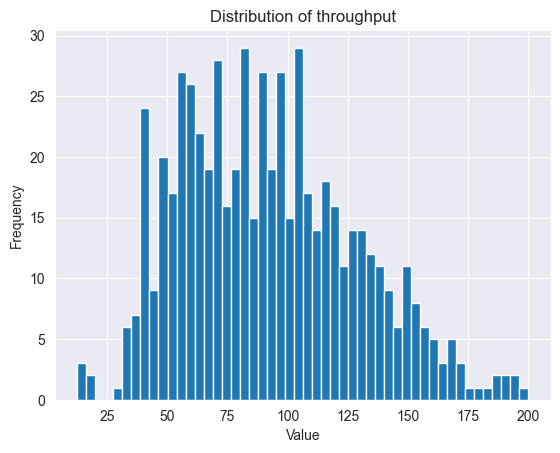

In [19]:
import matplotlib.pyplot as plt

df['throughput'].hist(bins=50)
plt.title('Distribution of throughput')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

In [20]:
from sklearn.preprocessing import MinMaxScaler

range_start = summary1['throughput_mean'].min() / summary1['throughput_mean'].max() * 1
path_range_start = summary1['path_len_mean'].min() / summary1['path_len_mean'].max() * 1
processing_time_range_start = summary1['processing_time_mean'].min() / summary1['processing_time_mean'].max() * 1

throughput_scaler = MinMaxScaler(feature_range=(round(float(range_start), 4), 1))
path_len_scaler = MinMaxScaler(feature_range=(round(float(path_range_start), 4), 1))
processing_time_scaler = MinMaxScaler(feature_range=(round(float(processing_time_range_start), 4), 1))

summary1['throughput_mean_standardized'] = throughput_scaler.fit_transform(
    summary1['throughput_mean'].values.reshape(-1, 1))
summary1['path_len_mean_standardized'] = path_len_scaler.fit_transform(summary1['path_len_mean'].values.reshape(-1, 1))
summary1['processing_time_mean_standardized'] = processing_time_scaler.fit_transform(
    summary1['processing_time_mean'].values.reshape(-1, 1))


In [21]:
summary1.head()

,model_id,correct_mean,answer_relevant_mean,context_relevant_mean,hallucination_mean,retrieval_failure_mean,confident_hallucination_mean,relevancy_score_mean,context_relevancy_score_mean,processing_time_mean,...,throughput_mean,failure_given_context_miss,success_given_context,context_induced_error_rate,context_sensitivity,failure_rate_mean,context_miss,throughput_mean_standardized,path_len_mean_standardized,processing_time_mean_standardized
0,8b_Q4,0.400000,0.733333,0.646667,0.360000,0.326667,0.100000,0.707623,0.601792,4.402275,...,106.768282,0.924528,0.577320,0.544444,0.501848,0.600000,0.353333,1.000000,0.946042,0.503200
1,8b_Q8,0.466667,0.780000,0.720000,0.366667,0.226667,0.046667,0.747397,0.668619,5.579038,...,101.058787,0.809524,0.574074,0.425000,0.383598,0.533333,0.280000,0.946526,0.960431,0.637696
2,8b_QF16,0.466667,0.793333,0.686667,0.393333,0.246667,0.073333,0.732097,0.654024,6.746503,...,87.702613,0.787234,0.582524,0.462500,0.369758,0.533333,0.313333,0.821435,1.000000,0.771130
3,openai,0.640000,0.926667,0.813333,0.340000,0.133333,0.060000,0.876355,0.781299,8.748976,...,72.024857,0.714286,0.721311,0.370370,0.435597,0.360000,0.186667,0.674600,0.618700,1.000000


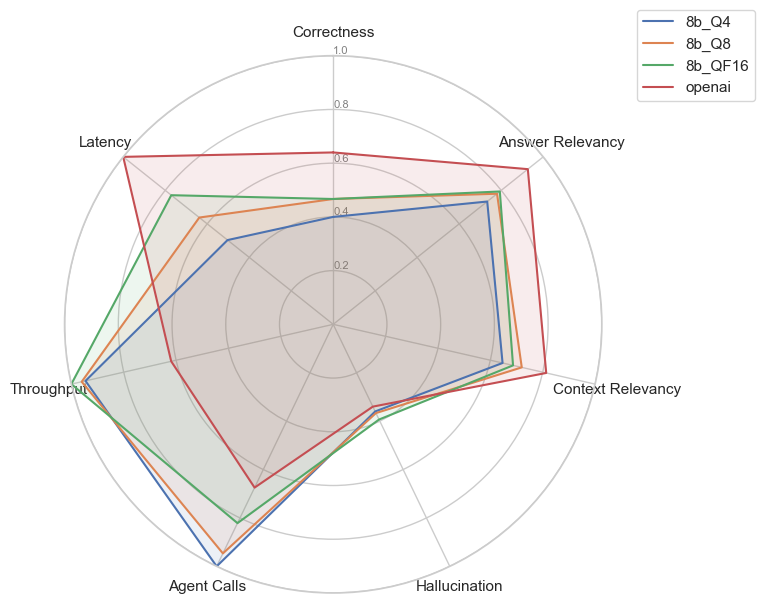

In [41]:
from math import pi

# Prepare data for radar plot
radar_metrics = [
    "correct_mean",
    "answer_relevant_mean",
    "context_relevant_mean",
    "hallucination_mean",
    "throughput_mean_standardized",
    "path_len_mean_standardized",
    "processing_time_mean_standardized",
]

radar_labels = [
    "Correctness",
    "Answer Relevancy",
    "Context Relevancy",
    "Hallucination",
    "Agent Calls",
    "Throughput",
    "Latency"
]

sensitivity_radar_metrics = [
    "failure_given_context_miss",
    "success_given_context",
    "failure_rate_mean",
    "context_induced_error_rate",
    "context_miss",
]

sensitivity_radar_labels = [
    "Context Driven Failure Rate",
    "Context Driven Success Rate",
    "Response Failure Rate",
    "Context Induced Failure Rate",
    "Context Miss",
]

# Function to create radar chart
def create_radar_chart(df, title, metrics, labels):
    num_vars = len(metrics)
    angles = [n / float(num_vars) * 2 * pi for n in range(num_vars)]
    angles += angles[:1]  # Complete the loop

    plt.figure(figsize=(8, 8))
    ax = plt.subplot(111, polar=True)

    for i, row in df.iterrows():
        values = row[metrics].tolist()
        values += values[:1]
        ax.plot(angles, values, label=row['model_id'])
        ax.fill(angles, values, alpha=0.1)

    ax.set_theta_offset(pi / 2)
    ax.set_theta_direction(-1)

    plt.xticks(angles[:-1], labels)
    ax.set_rlabel_position(0)
    plt.yticks([0.2, 0.4, 0.6, 0.8, 1.0], ["0.2", "0.4", "0.6", "0.8", "1.0"], color="grey", size=8)
    plt.ylim(0, 1)

    plt.title(title, size=15, color='black', y=1.1)
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.tight_layout()
    plt.show()


# Create the radar chart
create_radar_chart(summary1, "", metrics=radar_metrics, labels=radar_labels)


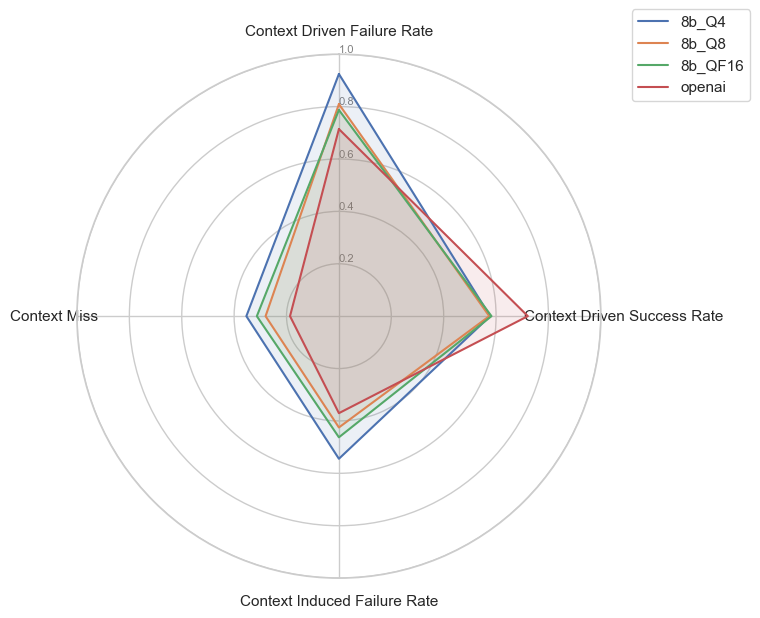

In [42]:
create_radar_chart(summary1, "", metrics=sensitivity_radar_metrics, labels=sensitivity_radar_labels)

In [24]:
# Compute summary metrics per model

# Compute summary metrics per model
summary_grouped = df.groupby(["model_id", "batch_id"])

summary_failure_metrics = summary_grouped.apply(lambda g: pd.Series({
    'context_driven_failure_rate': (
        ((~g['context_relevant']) & (~g['correct'])).sum() /
        (~g['context_relevant']).sum()
        if (~g['context_relevant']).sum() > 0 else 0
    ),
    'context_driven_success_rate': (
        ((g['context_relevant']) & (g['correct'])).sum() /
        (g['context_relevant']).sum()
        if (g['context_relevant']).sum() > 0 else 0
    ),
    'context_induced_error_rate': (
        ((~g['context_relevant']) & (~g['correct'])).sum() /
        (~g['correct']).sum()
        if (~g['correct']).sum() > 0 else 0
    ),
    'context_sensitivity': (
        g[g['context_relevant']]['correct'].mean() - g[~g['context_relevant']]['correct'].mean()
        if not g[g['context_relevant']]['correct'].empty and not g[~g['context_relevant']]['correct'].empty
        else 0
    )
})).reset_index()
summary = summary_grouped.agg({
    "correct": ["mean"],
    "answer_relevant": ["mean"],
    "context_relevant": ["mean"],
    "hallucination": ["mean"],
    "processing_time": ["mean"],
    "prompt_token_count": ["mean"],
    "response_token_count": ["mean"],
    "path_len": ["mean"],
})
summary.columns = ['_'.join(col).strip() for col in summary.columns.values]
summary.reset_index(inplace=True)

summary = pd.merge(summary_failure_metrics, summary, on=['model_id', 'batch_id'])

/var/folders/1p/zlvk2j_11h718fq9lpcl0wzm0000gn/T/ipykernel_70327/1015411805.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary_failure_metrics = summary_grouped.apply(lambda g: pd.Series({


In [25]:
summary.head(20)

,model_id,batch_id,context_driven_failure_rate,context_driven_success_rate,context_induced_error_rate,context_sensitivity,correct_mean,answer_relevant_mean,context_relevant_mean,hallucination_mean,processing_time_mean,prompt_token_count_mean,response_token_count_mean,path_len_mean
0,8b_Q4,TC1,1.000000,0.555556,0.600000,0.555556,0.333333,0.633333,0.600000,0.300000,4.468459,3342.466667,290.200000,1.733333
1,8b_Q4,TC2,1.000000,0.550000,0.526316,0.550000,0.366667,0.633333,0.666667,0.266667,4.395898,3534.633333,276.333333,1.800000
2,8b_Q4,TC3,0.846154,0.588235,0.611111,0.434389,0.400000,0.766667,0.566667,0.433333,4.033041,3439.433333,241.766667,1.733333
3,8b_Q4,TC4,1.000000,0.636364,0.500000,0.636364,0.466667,0.833333,0.733333,0.366667,4.975355,3781.000000,328.933333,1.866667
4,8b_Q4,TC5,0.800000,0.550000,0.470588,0.350000,0.433333,0.800000,0.666667,0.433333,4.138623,3400.200000,258.466667,1.633333
5,8b_Q8,TC1,0.750000,0.576923,0.214286,0.326923,0.533333,0.900000,0.866667,0.400000,6.500612,3720.233333,416.566667,1.866667
6,8b_Q8,TC2,0.818182,0.736842,0.642857,0.555024,0.533333,0.733333,0.633333,0.266667,6.717659,3789.066667,433.866667,1.866667
7,8b_Q8,TC3,0.900000,0.450000,0.450000,0.350000,0.333333,0.666667,0.666667,0.366667,4.751742,3262.633333,291.933333,1.633333
8,8b_Q8,TC4,0.666667,0.523810,0.375000,0.190476,0.466667,0.833333,0.700000,0.466667,4.633774,3300.133333,294.133333,1.633333
9,8b_Q8,TC5,0.875000,0.590909,0.437500,0.465909,0.466667,0.766667,0.733333,0.333333,5.291400,3679.766667,321.433333,1.900000


In [26]:
summary['correct_mean'] = (summary["correct_mean"] * 100).round(2)
summary['answer_relevant_mean'] = (summary["answer_relevant_mean"] * 100).round(2)
summary['context_relevant_mean'] = (summary["context_relevant_mean"] * 100).round(2)
summary['hallucination_mean'] = (summary["hallucination_mean"] * 100).round(2)

In [ ]:
# summary.drop(['relevancy_score_mean', 'context_relevancy_score_mean'], axis=1, inplace=True)

In [ ]:
# Define metrics
bar_metrics = ["correct_mean", "answer_relevant_mean", "context_relevant_mean"]
line_metrics = ["path_len_mean"]

# Plot
for bar_metric in bar_metrics:
    plt.figure(figsize=(14, 6))
    ax = sns.barplot(
        x="batch_id", y=bar_metric, hue="model_id", data=summary, palette="muted"
    )

    # # Overlay line plots
    # for line_metric in line_metrics:
    #     for model in summary["model_id"].unique():
    #         subset = summary[summary["model_id"] == model]
    #         ax2 = ax.twinx()
    #         ax2.plot(
    #             subset["batch_id"],
    #             subset[line_metric],
    #             label=f"{model} - {line_metric}",
    #             linestyle="--",
    #             marker="o"
    #         )

    ax.set_title(f"{bar_metric.replace('_mean', '').replace('_', ' ').title()} per Batch by Model")
    ax.set_ylabel(bar_metric.replace('_mean', '').replace('_', ' ').title())
    ax.set_xlabel("Batch ID")
    ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), borderaxespad=0)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [28]:
# Create bins or group by exact path lengths
path_analysis = df.groupby("path_len").agg({
    "correct": "mean",
    "relevancy_score": "mean",
    "context_relevancy_score": "mean",
    "processing_time": "mean",
    "prompt_token_count": "mean",
    "response_token_count": "mean",
    "throughput": "mean"  # optional, if you've calculated it
}).reset_index()

# Format percentages for readability (optional)
path_analysis["correct_percent"] = (path_analysis["correct"] * 100).round(2)

In [29]:
path_analysis.head()

,path_len,correct,relevancy_score,context_relevancy_score,processing_time,prompt_token_count,response_token_count,throughput,correct_percent
0,1,0.442446,0.713139,0.605598,4.865172,1965.888489,188.068345,72.633843,44.24
1,2,0.560150,0.806880,0.727705,6.464995,3932.251880,379.500000,108.463999,56.02
2,3,0.407407,0.826631,0.776558,13.390360,5252.907407,806.685185,109.361249,40.74
3,4,1.000000,1.000000,1.000000,13.116414,5332.500000,600.500000,92.020638,100.00


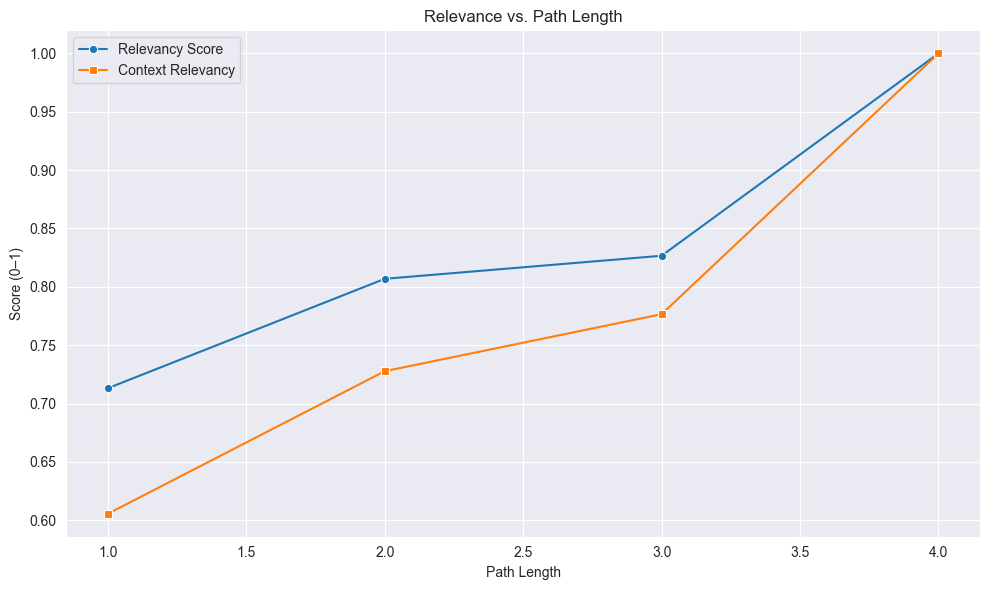

In [30]:
plt.figure(figsize=(10, 6))
sns.lineplot(x="path_len", y="relevancy_score", data=path_analysis, marker="o", label="Relevancy Score")
sns.lineplot(x="path_len", y="context_relevancy_score", data=path_analysis, marker="s", label="Context Relevancy")
plt.title("Relevance vs. Path Length")
plt.ylabel("Score (0–1)")
plt.xlabel("Path Length")
plt.legend()
plt.tight_layout()
plt.show()


In [31]:
summary.head()

,model_id,batch_id,context_driven_failure_rate,context_driven_success_rate,context_induced_error_rate,context_sensitivity,correct_mean,answer_relevant_mean,context_relevant_mean,hallucination_mean,processing_time_mean,prompt_token_count_mean,response_token_count_mean,path_len_mean
0,8b_Q4,TC1,1.000000,0.555556,0.600000,0.555556,33.33,63.33,60.00,30.00,4.468459,3342.466667,290.200000,1.733333
1,8b_Q4,TC2,1.000000,0.550000,0.526316,0.550000,36.67,63.33,66.67,26.67,4.395898,3534.633333,276.333333,1.800000
2,8b_Q4,TC3,0.846154,0.588235,0.611111,0.434389,40.00,76.67,56.67,43.33,4.033041,3439.433333,241.766667,1.733333
3,8b_Q4,TC4,1.000000,0.636364,0.500000,0.636364,46.67,83.33,73.33,36.67,4.975355,3781.000000,328.933333,1.866667
4,8b_Q4,TC5,0.800000,0.550000,0.470588,0.350000,43.33,80.00,66.67,43.33,4.138623,3400.200000,258.466667,1.633333


In [32]:
# ── 1.  START FROM YOUR `summary` DATAFRAME  ──────────────────────────────
# ▸ `summary` must contain one row per (model_id, batch_id) with:
#    - correct_mean
#    - relevancy_score_mean
#    - context_relevancy_score_mean
# If you haven’t built it yet, see the earlier aggregation snippet.

# Convert correctness to % for nicer axes
# summary["correct_mean_percent"] = (summary["correct_mean"] * 100).round(2)
# summary["relevant_mean_percent"] = (summary["answer_relevant_mean"] * 100).round(2)
# summary["context_relevant_mean_percent"] = (summary["context_relevant_mean"] * 100).round(2)


In [33]:
summary.head()

,model_id,batch_id,context_driven_failure_rate,context_driven_success_rate,context_induced_error_rate,context_sensitivity,correct_mean,answer_relevant_mean,context_relevant_mean,hallucination_mean,processing_time_mean,prompt_token_count_mean,response_token_count_mean,path_len_mean
0,8b_Q4,TC1,1.000000,0.555556,0.600000,0.555556,33.33,63.33,60.00,30.00,4.468459,3342.466667,290.200000,1.733333
1,8b_Q4,TC2,1.000000,0.550000,0.526316,0.550000,36.67,63.33,66.67,26.67,4.395898,3534.633333,276.333333,1.800000
2,8b_Q4,TC3,0.846154,0.588235,0.611111,0.434389,40.00,76.67,56.67,43.33,4.033041,3439.433333,241.766667,1.733333
3,8b_Q4,TC4,1.000000,0.636364,0.500000,0.636364,46.67,83.33,73.33,36.67,4.975355,3781.000000,328.933333,1.866667
4,8b_Q4,TC5,0.800000,0.550000,0.470588,0.350000,43.33,80.00,66.67,43.33,4.138623,3400.200000,258.466667,1.633333


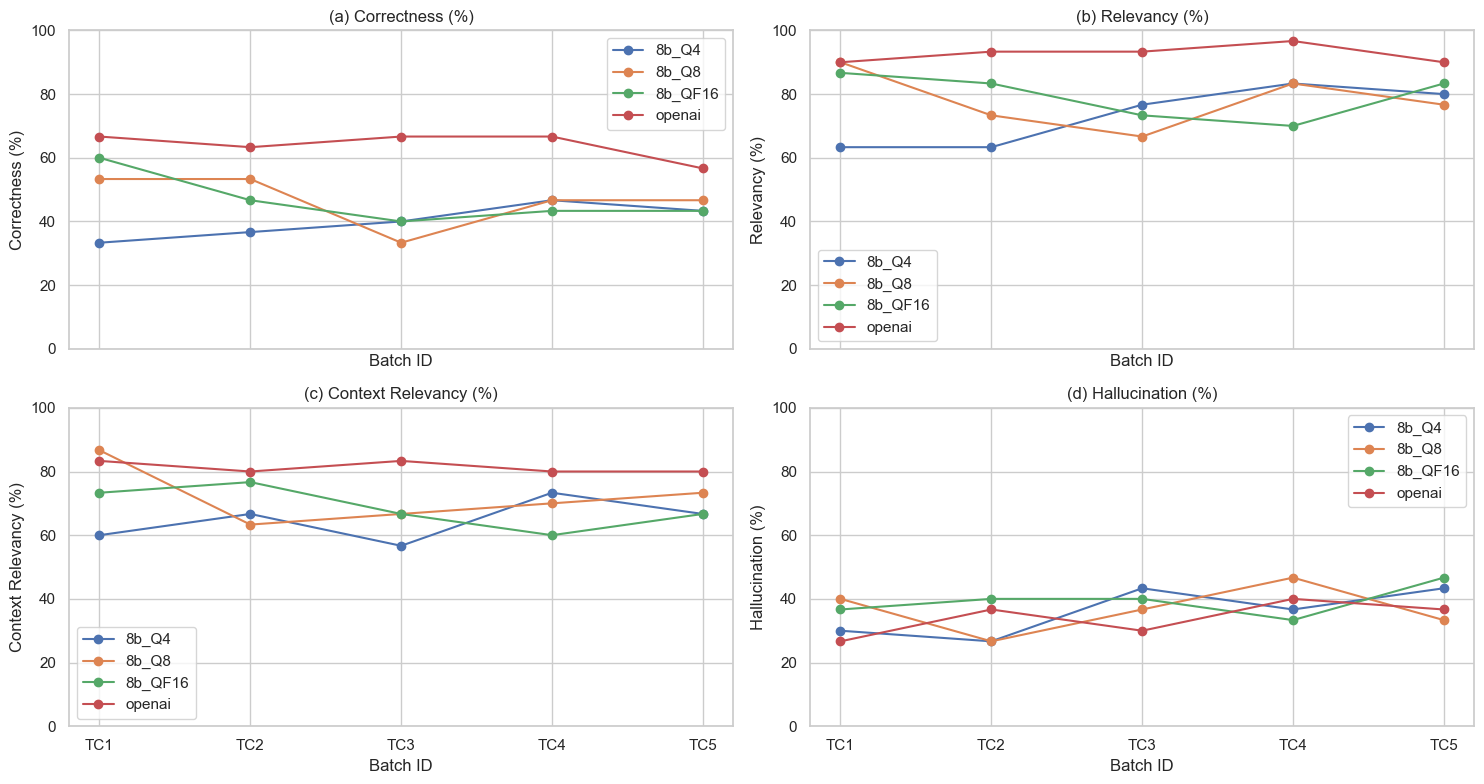

In [34]:
# ── 2.  PLOT SET-UP  ─────────────────────────────────────────────────────
sns.set(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(15, 8), sharex=True)
axes_flat = axes.flatten()
letters = ['(a)', '(b)', '(c)', '(d)']  # subplot labels

# Metric mapping:  title → column in `summary`
metrics = {
    "Correctness (%)": "correct_mean",
    "Relevancy (%)": "answer_relevant_mean",
    "Context Relevancy (%)": "context_relevant_mean",
    "Hallucination (%)": "hallucination_mean"
}

# ── 3.  DRAW EACH LINE CHART  ────────────────────────────────────────────
for idx, (title, col) in enumerate(metrics.items()):
    ax = axes_flat[idx]
    for model in summary["model_id"].unique():  # one line per model
        subset = summary[summary["model_id"] == model]
        ax.plot(subset["batch_id"],
                subset[col],
                marker="o",
                label=model)
    ax.set_title(f"{letters[idx]} {title}")
    ax.set_xlabel("Batch ID")
    ax.set_ylabel(title)
    ax.set_ylim(0, 100)
    ax.legend()

# Optional: remove the unused “(d)” subplot
# fig.delaxes(axes_flat[3])

plt.tight_layout()
plt.show()


In [35]:
summary.head()

,model_id,batch_id,context_driven_failure_rate,context_driven_success_rate,context_induced_error_rate,context_sensitivity,correct_mean,answer_relevant_mean,context_relevant_mean,hallucination_mean,processing_time_mean,prompt_token_count_mean,response_token_count_mean,path_len_mean
0,8b_Q4,TC1,1.000000,0.555556,0.600000,0.555556,33.33,63.33,60.00,30.00,4.468459,3342.466667,290.200000,1.733333
1,8b_Q4,TC2,1.000000,0.550000,0.526316,0.550000,36.67,63.33,66.67,26.67,4.395898,3534.633333,276.333333,1.800000
2,8b_Q4,TC3,0.846154,0.588235,0.611111,0.434389,40.00,76.67,56.67,43.33,4.033041,3439.433333,241.766667,1.733333
3,8b_Q4,TC4,1.000000,0.636364,0.500000,0.636364,46.67,83.33,73.33,36.67,4.975355,3781.000000,328.933333,1.866667
4,8b_Q4,TC5,0.800000,0.550000,0.470588,0.350000,43.33,80.00,66.67,43.33,4.138623,3400.200000,258.466667,1.633333


    batch_id  question_id  processing_time  prompt_token_count  \
0        TC3            1         3.609839                3170   
1        TC3            2         3.010035                2907   
2        TC3            3         2.874345                3406   
3        TC3            4         5.970746                4325   
4        TC3            5         7.875904                3578   
..       ...          ...              ...                 ...   
145      TC1           26         1.655942                2128   
146      TC1           27         6.851086                3670   
147      TC1           28         3.227192                3919   
148      TC1           29         2.461425                2218   
149      TC1           30         1.958774                2174   

     response_token_count  correct  answer_relevant  context_relevant  \
0                     158    False             True             False   
1                     179    False             True          

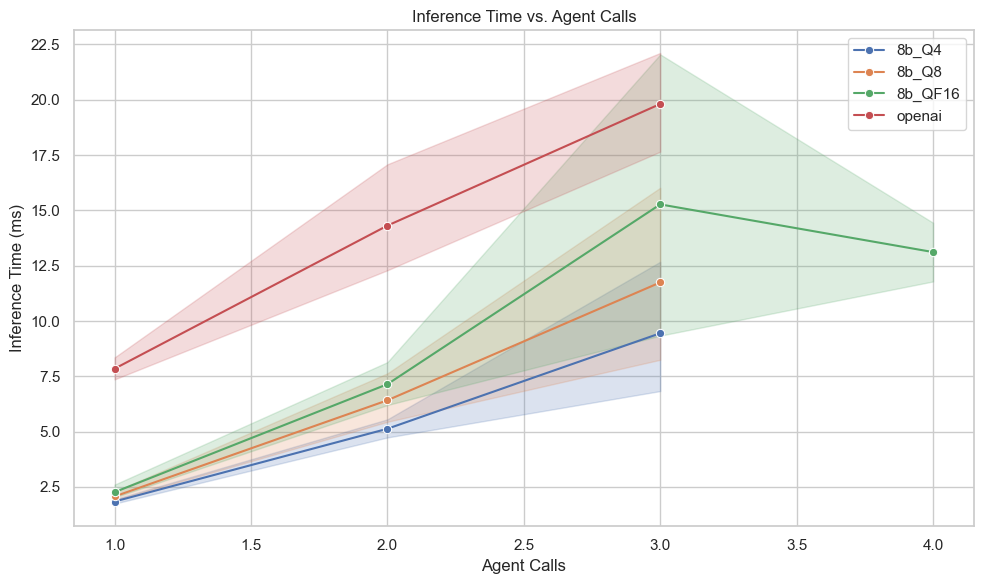

In [36]:

# Plotting
plt.figure(figsize=(10, 6))
for model in df["model_id"].unique():  # one line per model
    subset = df[df["model_id"] == model]
    print(subset)
    sns.lineplot(x="path_len", y="processing_time", data=subset, marker="o", label=model)

    # ax.plot(subset["path_len_mean"],
    #         subset["processing_time_mean"],
    #         marker="o",
    #         label=model)

plt.title('Inference Time vs. Agent Calls')
plt.xlabel('Agent Calls')
plt.ylabel('Inference Time (ms)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [40]:
summary.head()

,model_id,batch_id,context_driven_failure_rate,context_driven_success_rate,context_induced_error_rate,context_sensitivity,correct_mean,answer_relevant_mean,context_relevant_mean,hallucination_mean,processing_time_mean,prompt_token_count_mean,response_token_count_mean,path_len_mean
0,8b_Q4,TC1,1.000000,0.555556,0.600000,0.555556,33.33,63.33,60.00,30.00,4.468459,3342.466667,290.200000,1.733333
1,8b_Q4,TC2,1.000000,0.550000,0.526316,0.550000,36.67,63.33,66.67,26.67,4.395898,3534.633333,276.333333,1.800000
2,8b_Q4,TC3,0.846154,0.588235,0.611111,0.434389,40.00,76.67,56.67,43.33,4.033041,3439.433333,241.766667,1.733333
3,8b_Q4,TC4,1.000000,0.636364,0.500000,0.636364,46.67,83.33,73.33,36.67,4.975355,3781.000000,328.933333,1.866667
4,8b_Q4,TC5,0.800000,0.550000,0.470588,0.350000,43.33,80.00,66.67,43.33,4.138623,3400.200000,258.466667,1.633333


In [43]:
final_summary = summary.groupby("model_id").agg({
    "correct_mean": "mean",
    "answer_relevant_mean": "mean",
    "context_relevant_mean": "mean",
    "hallucination_mean": "mean",
    "context_driven_success_rate": "mean",
    "context_driven_failure_rate": "mean",
    "processing_time_mean": "mean",
    "path_len_mean": "mean",
}).reset_index()

In [45]:
final_summary['context_driven_success_rate'] = (final_summary['context_driven_success_rate'] * 100).round(2)
final_summary['context_driven_failure_rate'] = (final_summary['context_driven_failure_rate'] * 100).round(2)

In [46]:
final_summary.head()

,model_id,correct_mean,answer_relevant_mean,context_relevant_mean,hallucination_mean,context_driven_success_rate,context_driven_failure_rate,processing_time_mean,path_len_mean
0,8b_Q4,40.000,73.332,64.668,36.000,57.60,92.92,4.402275,1.753333
1,8b_Q8,46.666,78.000,72.000,36.668,57.57,80.20,5.579038,1.780000
2,8b_QF16,46.666,79.332,68.668,39.334,58.16,78.31,6.746503,1.853333
3,openai,64.002,92.666,81.332,34.002,72.07,72.00,8.748976,1.146667


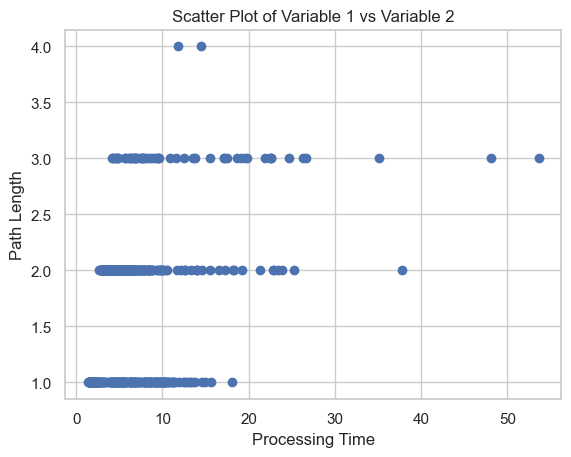

In [353]:

plt.scatter(df['processing_time'], df['path_len'])
plt.xlabel('Processing Time')
plt.ylabel('Path Length')
plt.title('Scatter Plot of Variable 1 vs Variable 2')
plt.show()

In [ ]:
# from deepeval.metrics import HallucinationMetric, UnBiasedMetric, NonToxicMetric


In [ ]:
filtered_df = df[(df['answer_relevant'] == False) & (df['correct'] == True)]


In [239]:
count = df[(df["answer_relevant"] == True) & (df["correct"] == True)].shape[0]

In [240]:
count

281

In [241]:
df[(df["answer_relevant"] == True) & (df["correct"] == True)].shape[0]

281

In [243]:
df[(df["answer_relevant"] == False) & (df["correct"] == True)]

,batch_id,question_id,processing_time,prompt_token_count,response_token_count,correct,answer_relevant,context_relevant,relevancy_score,context_relevancy_score,path,path_len,model_id,throughput,hallucination
2,TC3,3,2.874345,3406,88,True,False,False,0.333333,0.500000,"[job_application_tool, job_description_tool]",2,8b_Q4,30.615665,False
20,TC3,21,5.130638,3717,346,True,False,False,0.500000,0.416667,"[job_application_tool, job_description_tool]",2,8b_Q4,67.438006,False
50,TC2,21,4.176718,3449,239,True,False,True,0.375000,0.666667,"[job_application_tool, job_description_tool]",2,8b_Q4,57.221961,False
64,TC5,5,5.375325,3073,422,True,False,True,0.444444,1.000000,"[job_application_tool, job_post_tool]",2,8b_Q4,78.506884,False
80,TC5,21,3.743922,3313,246,True,False,False,0.312500,0.500000,"[job_application_tool, job_description_tool]",2,8b_Q4,65.706491,False
118,TC4,29,2.491599,2212,158,True,False,True,0.200000,1.000000,[job_application_tool],1,8b_Q4,63.413086,False
200,TC2,21,8.053379,3951,613,True,False,True,0.111111,0.705882,"[job_application_tool, job_description_tool]",2,8b_Q8,76.117118,False
255,TC4,16,7.307815,3773,620,True,False,True,0.470588,0.888889,"[job_description_tool, job_application_tool]",2,8b_Q8,84.840677,False
329,TC3,30,3.424613,2244,174,True,False,True,0.200000,1.000000,[job_application_tool],1,8b_QF16,50.808655,False
379,TC5,20,4.891369,3419,203,True,False,True,0.500000,0.750000,"[job_description_tool, job_application_tool]",2,8b_QF16,41.501671,False


In [244]:
df.head()

,batch_id,question_id,processing_time,prompt_token_count,response_token_count,correct,answer_relevant,context_relevant,relevancy_score,context_relevancy_score,path,path_len,model_id,throughput,hallucination
0,TC3,1,3.609839,3170,158,False,True,False,1.000000,0.500000,"[job_description_tool, job_application_tool]",2,8b_Q4,43.769263,True
1,TC3,2,3.010035,2907,179,False,True,True,1.000000,0.833333,[job_application_tool],1,8b_Q4,59.467743,True
2,TC3,3,2.874345,3406,88,True,False,False,0.333333,0.500000,"[job_application_tool, job_description_tool]",2,8b_Q4,30.615665,False
3,TC3,4,5.970746,4325,374,False,True,True,1.000000,0.750000,"[job_description_tool, job_application_tool]",2,8b_Q4,62.638743,True
4,TC3,5,7.875904,3578,637,True,True,True,1.000000,1.000000,"[job_application_tool, job_post_tool]",2,8b_Q4,80.879606,False


In [293]:
grouped = df.groupby(['model_id', 'batch_id'])

In [246]:
grouped.head()

,batch_id,question_id,processing_time,prompt_token_count,response_token_count,correct,answer_relevant,context_relevant,relevancy_score,context_relevancy_score,path,path_len,model_id,throughput,hallucination
0,TC3,1,3.609839,3170,158,False,True,False,1.000000,0.500000,"[job_description_tool, job_application_tool]",2,8b_Q4,43.769263,True
1,TC3,2,3.010035,2907,179,False,True,True,1.000000,0.833333,[job_application_tool],1,8b_Q4,59.467743,True
2,TC3,3,2.874345,3406,88,True,False,False,0.333333,0.500000,"[job_application_tool, job_description_tool]",2,8b_Q4,30.615665,False
3,TC3,4,5.970746,4325,374,False,True,True,1.000000,0.750000,"[job_description_tool, job_application_tool]",2,8b_Q4,62.638743,True
4,TC3,5,7.875904,3578,637,True,True,True,1.000000,1.000000,"[job_application_tool, job_post_tool]",2,8b_Q4,80.879606,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
570,TC1,1,13.747982,1726,490,True,True,True,1.000000,0.900000,[job_application_tool],1,openai,35.641594,False
571,TC1,2,5.940049,2180,162,True,True,True,1.000000,1.000000,[job_application_tool],1,openai,27.272501,False
572,TC1,3,3.384536,1480,26,True,True,True,1.000000,1.000000,[job_application_tool],1,openai,7.681998,False
573,TC1,4,6.239649,1230,123,False,False,False,0.250000,0.000000,[job_description_tool],1,openai,19.712649,False


In [268]:
mean_metrics = grouped[['correct', 'answer_relevant', 'context_relevant']].mean().reset_index()

In [269]:
mean_metrics

,model_id,batch_id,correct,answer_relevant,context_relevant
0,8b_Q4,TC1,0.333333,0.633333,0.600000
1,8b_Q4,TC2,0.366667,0.600000,0.666667
2,8b_Q4,TC3,0.400000,0.700000,0.566667
3,8b_Q4,TC4,0.466667,0.800000,0.733333
4,8b_Q4,TC5,0.433333,0.733333,0.666667
5,8b_Q8,TC1,0.533333,0.900000,0.866667
6,8b_Q8,TC2,0.533333,0.700000,0.633333
7,8b_Q8,TC3,0.333333,0.666667,0.666667
8,8b_Q8,TC4,0.466667,0.800000,0.700000
9,8b_Q8,TC5,0.466667,0.766667,0.733333


In [257]:
grouped

In [294]:
fgcm = grouped.apply(
    lambda g: (
            ((~g['context_relevant']) & (~g['correct'])).sum() /
            (~g['context_relevant']).sum()
    ) if (~g['context_relevant']).sum() > 0 else 0,
).reset_index(name='failure_given_context_miss')


/var/folders/1p/zlvk2j_11h718fq9lpcl0wzm0000gn/T/ipykernel_26189/3569075473.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fgcm = grouped.apply(


In [295]:
fgcm

,model_id,batch_id,failure_given_context_miss
0,8b_Q4,TC1,1.000000
1,8b_Q4,TC2,1.000000
2,8b_Q4,TC3,0.846154
3,8b_Q4,TC4,1.000000
4,8b_Q4,TC5,0.800000
5,8b_Q8,TC1,0.750000
6,8b_Q8,TC2,0.818182
7,8b_Q8,TC3,0.900000
8,8b_Q8,TC4,0.666667
9,8b_Q8,TC5,0.875000


In [251]:
fgcm

,model_id,batch_id,failure_given_context_miss
0,8b_Q4,TC1,1.000000
1,8b_Q4,TC2,1.000000
2,8b_Q4,TC3,0.846154
3,8b_Q4,TC4,1.000000
4,8b_Q4,TC5,0.800000
5,8b_Q8,TC1,0.750000
6,8b_Q8,TC2,0.818182
7,8b_Q8,TC3,0.900000
8,8b_Q8,TC4,0.666667
9,8b_Q8,TC5,0.875000


In [296]:
aggregated_results = pd.merge(mean_metrics, fgcm, on=['model_id', 'batch_id'])

In [253]:
aggregated_results

,model_id,batch_id,correct,answer_relevant,context_relevant,failure_given_context_miss
0,8b_Q4,TC1,0.333333,0.633333,0.600000,1.000000
1,8b_Q4,TC2,0.366667,0.600000,0.666667,1.000000
2,8b_Q4,TC3,0.400000,0.700000,0.566667,0.846154
3,8b_Q4,TC4,0.466667,0.800000,0.733333,1.000000
4,8b_Q4,TC5,0.433333,0.733333,0.666667,0.800000
5,8b_Q8,TC1,0.533333,0.900000,0.866667,0.750000
6,8b_Q8,TC2,0.533333,0.700000,0.633333,0.818182
7,8b_Q8,TC3,0.333333,0.666667,0.666667,0.900000
8,8b_Q8,TC4,0.466667,0.800000,0.700000,0.666667
9,8b_Q8,TC5,0.466667,0.766667,0.733333,0.875000


In [261]:
df.loc[(df['correct'] == True) & (df['answer_relevant'] == False), 'answer_relevant'] = True

,batch_id,question_id,processing_time,prompt_token_count,response_token_count,correct,answer_relevant,context_relevant,relevancy_score,context_relevancy_score,path,path_len,model_id,throughput,hallucination,retrieval_failure,confident_hallucination
2,TC3,3,2.874345,3406,88,True,False,False,0.333333,0.500000,"[job_application_tool, job_description_tool]",2,8b_Q4,61.231331,False,False,False
20,TC3,21,5.130638,3717,346,True,False,False,0.500000,0.416667,"[job_application_tool, job_description_tool]",2,8b_Q4,134.876012,False,False,False
50,TC2,21,4.176718,3449,239,True,False,True,0.375000,0.666667,"[job_application_tool, job_description_tool]",2,8b_Q4,114.443922,False,False,False
64,TC5,5,5.375325,3073,422,True,False,True,0.444444,1.000000,"[job_application_tool, job_post_tool]",2,8b_Q4,157.013768,False,False,False
80,TC5,21,3.743922,3313,246,True,False,False,0.312500,0.500000,"[job_application_tool, job_description_tool]",2,8b_Q4,131.412982,False,False,False
118,TC4,29,2.491599,2212,158,True,False,True,0.200000,1.000000,[job_application_tool],1,8b_Q4,126.826171,False,False,False
200,TC2,21,8.053379,3951,613,True,False,True,0.111111,0.705882,"[job_application_tool, job_description_tool]",2,8b_Q8,152.234236,False,False,False
255,TC4,16,7.307815,3773,620,True,False,True,0.470588,0.888889,"[job_description_tool, job_application_tool]",2,8b_Q8,169.681353,False,False,False
329,TC3,30,3.424613,2244,174,True,False,True,0.200000,1.000000,[job_application_tool],1,8b_QF16,101.617310,False,False,False
379,TC5,20,4.891369,3419,203,True,False,True,0.500000,0.750000,"[job_description_tool, job_application_tool]",2,8b_QF16,83.003341,False,False,False
